# Лабораторная работа №1. Регрессия и метод главных компонент

## 1. Введение

**Цель работы** - изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество.

**Задачи:**

1. Загрузить датасет Boston Housing (boston_housing.csv).
2. Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной.
3. Провести предобработку данных: удалить пропущенные значения, закодировать категориальные переменные (опционально).
4. Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности (расчет VIF-коэффициента).
5. Построить регрессионные модели (линейная, лассо и гребневая). Если целевая переменная - категориальная, то исследовать логистическую регрессию. Разделить на тренировочную и тестовую выборки (80/20 или 70/30). Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: RMSE (Root Mean Square Error), R² (коэффициент детерминации) и MAPE (Mean Absolute Percentage Error).
6. Построить график остатков моделей (добавить горизонтальную линию на уровне 0) и исследовать структуру остатков на предмет гомоскедастичности или гетероскедастичности.
7. Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA). Перед проведением PCA провести стандартизацию данных.
8. Повторить шаг 5 (линейная, лассо и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.

Целевая переменная непрерывная - медианная цена жилья, потому логистическая регрессия здесь не нужна.


## 2. Описание датасета

Датасет [Boston Housing dataset](https://www.kaggle.com/datasets/arunjangir245/boston-housing-dataset). 506 строк, 14 столбцов.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "Segoe UI"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["figure.dpi"] = 110

RU_NAMES = {
    "crim": "Преступность",
    "zn": "Крупные участки",
    "indus": "Доля промзон",
    "chas": "Река Чарльз",
    "nox": "Оксиды азота",
    "rm": "Число комнат",
    "age": "Старый жилфонд",
    "dis": "Удалённость",
    "rad": "Индекс шоссе",
    "tax": "Налог",
    "ptratio": "Ученики/учитель",
    "b": "Индекс B",
    "lstat": "Низкий статус",
    "medv": "Цена жилья",
}

df = pd.read_csv("data/boston_housing.csv")
df_ru = df.rename(columns=RU_NAMES)

print("=" * 80)
print(f"Размерность: {df_ru.shape[0]} районов, {df_ru.shape[1]} столбцов (13 признаков + цена)")
print("=" * 80)
print("\nПервые 5 строк:")
print(df_ru.head().to_string())
print("\nПропущенные значения:")
print(df_ru.isnull().sum().to_string())
print(f"\nДубликаты: {int(df_ru.duplicated().sum())}")
print(f"Районов с ценой ровно 50 тыс. $: {int((df_ru['Цена жилья'] == 50).sum())}")


Размерность: 506 районов, 14 столбцов (13 признаков + цена)

Первые 5 строк:
   Преступность  Крупные участки  Доля промзон  Река Чарльз  Оксиды азота  Число комнат  Старый жилфонд  Удалённость  Индекс шоссе  Налог  Ученики/учитель  Индекс B  Низкий статус  Цена жилья
0       0.00632             18.0          2.31            0         0.538         6.575            65.2       4.0900             1    296             15.3    396.90           4.98        24.0
1       0.02731              0.0          7.07            0         0.469         6.421            78.9       4.9671             2    242             17.8    396.90           9.14        21.6
2       0.02729              0.0          7.07            0         0.469         7.185            61.1       4.9671             2    242             17.8    392.83           4.03        34.7
3       0.03237              0.0          2.18            0         0.458         6.998            45.8       6.0622             3    222             18.7 

Столбцы:

| Столбец | Смысл |
|---|---|
| Преступность (`crim`) | Число преступлений на душу населения |
| Крупные участки (`zn`) | Доля жилой земли под участки больше 25 000 кв. футов, % |
| Доля промзон (`indus`) | Доля земли не под торговлю, % |
| Река Чарльз (`chas`) | 1 - район выходит к реке, 0 - нет |
| Оксиды азота (`nox`) | Концентрация NOX, частей на 10 млн |
| Число комнат (`rm`) | Среднее число комнат в доме |
| Старый жилфонд (`age`) | Доля домов, построенных до 1940 года, % |
| Удалённость (`dis`) | Взвешенное расстояние до пяти центров занятости |
| Индекс шоссе (`rad`) | Доступность радиальных магистралей |
| Налог (`tax`) | Ставка налога на имущество на 10 000 $ |
| Ученики/учитель (`ptratio`) | Нагрузка на учителя в школах района |
| Индекс B (`b`) | \(1000(B_k - 0.63)^2\), где \(B_k\) - доля чернокожего населения. |
| Низкий статус (`lstat`) | Доля населения с низким социальным статусом, % |
| Цена жилья (`medv`) | **Цель:** медианная цена дома, занимаемого владельцем, в тысячах долларов |


In [2]:
numeric_cols = [c for c in df_ru.columns if c != "Река Чарльз"]
stats_df = df_ru[numeric_cols].describe().T
stats_df["Медиана"] = df_ru[numeric_cols].median()
stats_df["Межквартильный размах (IQR)"] = stats_df["75%"] - stats_df["25%"]
stats_df["Коэффициент асимметрии"] = df_ru[numeric_cols].skew()
stats_df = stats_df.rename(columns={
    "mean": "Среднее",
    "std": "Станд. откл.",
    "min": "Минимум",
    "max": "Максимум",
})
cols_order = [
    "Среднее", "Станд. откл.", "Медиана", "Межквартильный размах (IQR)",
    "Минимум", "Максимум", "Коэффициент асимметрии",
]
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
print(stats_df[cols_order].round(2).to_string())

print("\nРека Чарльз:")
chas_counts = df_ru["Река Чарльз"].value_counts().sort_index()
chas_share = df_ru["Река Чарльз"].value_counts(normalize=True).sort_index() * 100
print(pd.DataFrame({
    "Районов": chas_counts,
    "Доля, %": chas_share.round(2),
}).rename(index={0: "Не у реки", 1: "У реки"}).to_string())

mask_rad = df_ru["Индекс шоссе"] == 24
print(f"\nРайонов с индексом шоссе = 24: {int(mask_rad.sum())} ({mask_rad.mean() * 100:.1f}%)")
print("Налог в этих районах:", sorted(df_ru.loc[mask_rad, "Налог"].unique().tolist()))
print(f"Доля нулей в «Крупные участки»: {(df_ru['Крупные участки'] == 0).mean() * 100:.1f}%")


ОПИСАТЕЛЬНАЯ СТАТИСТИКА
                 Среднее  Станд. откл.  Медиана  Межквартильный размах (IQR)  Минимум  Максимум  Коэффициент асимметрии
Преступность        3.61          8.60     0.26                         3.60     0.01     88.98                    5.22
Крупные участки    11.36         23.32     0.00                        12.50     0.00    100.00                    2.23
Доля промзон       11.14          6.86     9.69                        12.91     0.46     27.74                    0.30
Оксиды азота        0.55          0.12     0.54                         0.18     0.38      0.87                    0.73
Число комнат        6.28          0.70     6.21                         0.74     3.56      8.78                    0.40
Старый жилфонд     68.57         28.15    77.50                        49.05     2.90    100.00                   -0.60
Удалённость         3.80          2.11     3.21                         3.09     1.13     12.13                    1.01
Индекс шоссе    

### Пояснение к описательной статистике

Цена жилья в среднем 22.53 тыс. долларов (около 22 500 долларов), медиана 21.20. Среднее выше медианы, асимметрия +1.11: хвост дорогих районов тянет среднее вверх, искусственный потолок 50. Разброс - стандартное отклонение 9.20 тыс. долларов, межквартильный размах около 8 тыс. долларов.

Оксиды азота - доли единицы (среднее 0.55), налог - сотни (среднее 408), индекс B - около 357. Без стандартизации гребневая регрессия, лассо и PCA будут смотреть на налог и B, поскольку у них большие числа.

Отдельные особенности формы:

- **Преступность** сильно скошена вправо (асимметрия +5.22): медиана 0.26, среднее 3.61, максимум 88.98. Несколько районов с очень высокой преступностью тянут линейную связь.
- **Крупные участки** у 73.5% районов равны нулю.
- **Число комнат** почти симметрично вокруг 6.2–6.3 комнаты. Это один из двух самых сильных спутников цены.
- **Низкий статус** в среднем 12.65%, медиана 11.36, асимметрия +0.91.
- **Река Чарльз** - редкий признак: только 35 районов из 506 (6.92%) выходят к реке.
- **Индекс шоссе** не гладкий. У 132 районов (26.1%) он равен 24, и у всех них налог равен 666. Это одна и та же группа наблюдений, записанная двумя столбцами. Далее возьмётся корреляция 0.91 и высокий VIF.


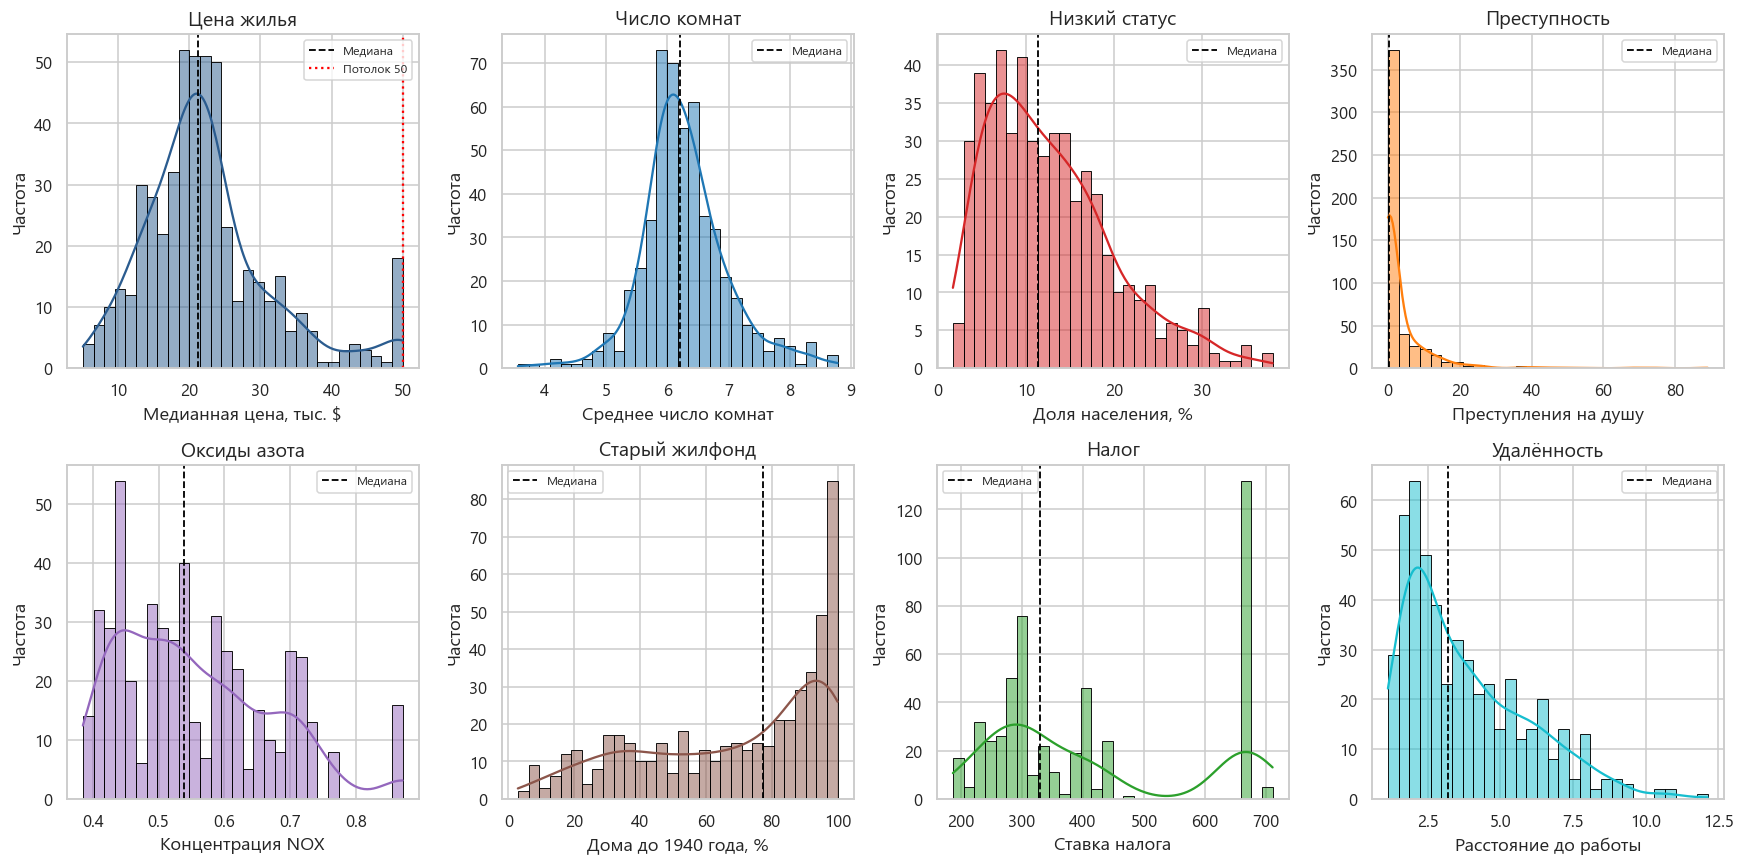

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
plot_specs = [
    ("Цена жилья", "Медианная цена, тыс. $", "#2b5c8f"),
    ("Число комнат", "Среднее число комнат", "#1f77b4"),
    ("Низкий статус", "Доля населения, %", "#d62728"),
    ("Преступность", "Преступления на душу", "#ff7f0e"),
    ("Оксиды азота", "Концентрация NOX", "#9467bd"),
    ("Старый жилфонд", "Дома до 1940 года, %", "#8c564b"),
    ("Налог", "Ставка налога", "#2ca02c"),
    ("Удалённость", "Расстояние до работы", "#17becf"),
]
for ax, (col, xlabel, color) in zip(axes.ravel(), plot_specs):
    sns.histplot(df_ru[col], kde=True, ax=ax, color=color, bins=30, edgecolor="black")
    ax.axvline(df_ru[col].median(), color="black", linestyle="--", linewidth=1.2, label="Медиана")
    ax.set_title(col)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Частота")
    ax.legend(fontsize=8)
axes[0, 0].axvline(50, color="red", linestyle=":", linewidth=1.5, label="Потолок 50")
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()


### Пояснение к графикам распределения

Цена жилья одновершинная, около 20–25 тыс. долларов и тонким правым хвостом. Красная линия на 50 - не естественный максимум рынка, а обрезка данных: 16 районов сложены в одну точку.

Число комнат около 6. Низкий статус смещён влево и имеет длинный правый хвост: большинство районов в диапазоне примерно 5–17%, но есть территории за 30%. Преступность почти у нуля, что видно на гистограмме - линейная модель будет чувствительна к нескольким крайним районам.

Налог: отдельным столбиком на 666 являются те 132 района с индексом шоссе 24. Старый жилфонд сдвинут вправо, много районов почти целиком застроены до 1940 года. Удалённость скошена: больше районов близко к центрам занятости, чем далеко.


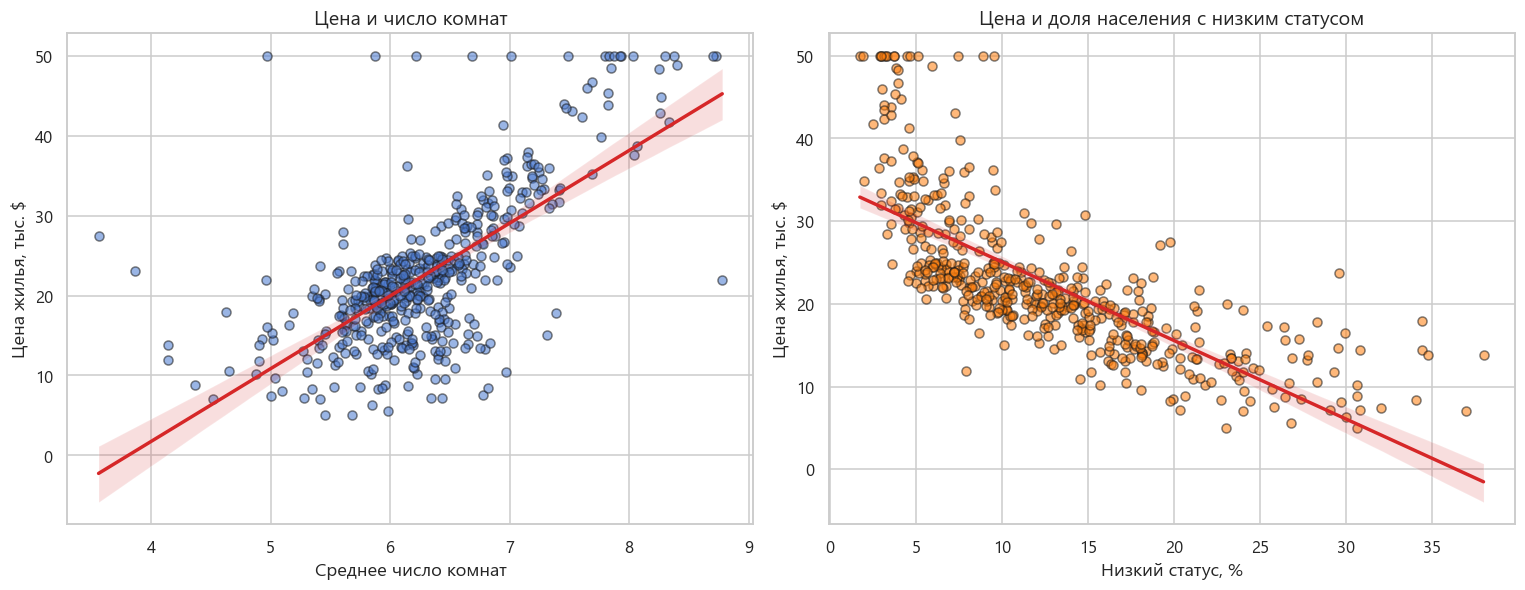

Корреляция выбранных признаков с ценой и между собой:
                 Число комнат  Низкий статус  Ученики/учитель  Цена жилья
Число комнат            1.000         -0.614           -0.356       0.695
Низкий статус          -0.614          1.000            0.374      -0.738
Ученики/учитель        -0.356          0.374            1.000      -0.508
Цена жилья              0.695         -0.738           -0.508       1.000


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.regplot(
    data=df_ru, x="Число комнат", y="Цена жилья",
    ax=axes[0], scatter_kws={"alpha": 0.55, "s": 35, "edgecolor": "k"},
    line_kws={"color": "#d62728"},
)
axes[0].set_title("Цена и число комнат")
axes[0].set_xlabel("Среднее число комнат")
axes[0].set_ylabel("Цена жилья, тыс. $")

sns.regplot(
    data=df_ru, x="Низкий статус", y="Цена жилья",
    ax=axes[1], scatter_kws={"alpha": 0.55, "s": 35, "edgecolor": "k", "color": "#ff7f0e"},
    line_kws={"color": "#d62728"},
)
axes[1].set_title("Цена и доля населения с низким статусом")
axes[1].set_xlabel("Низкий статус, %")
axes[1].set_ylabel("Цена жилья, тыс. $")

plt.tight_layout()
plt.show()

focus = df_ru[["Число комнат", "Низкий статус", "Ученики/учитель", "Цена жилья"]].corr()
print("Корреляция выбранных признаков с ценой и между собой:")
print(focus.round(3).to_string())


### Пояснение к связи признаков с ценой

Число комнат и цена идут вверх: больше комнат - дороже дом. Связь близка к прямой, однако наверху (цена 50) точки ложатся горизонтальной полкой из-за потолка. Корреляция Пирсона +0.70.

Доля населения с низким статусом и цена идут вниз. Облако немного загибается: на малых значениях `lstat` цена падает круче, чем на больших. Корреляция −0.74.

Ученики на учителя связаны с ценой отрицательно (около −0.51): в районах с перегруженными школами жильё дешевле. Эти три связи оправдывают регрессию. Остальные признаки слабее, но часть из них дублирует друг друга.


In [5]:
feature_names = [c for c in df_ru.columns if c != "Цена жилья"]
X = df_ru[feature_names]
y = df_ru["Цена жилья"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=feature_names, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=feature_names, index=X_test.index
)

print(f"Обучающая выборка: {X_train_scaled.shape[0]} районов, {X_train_scaled.shape[1]} признаков")
print(f"Тестовая выборка:  {X_test_scaled.shape[0]} районов, {X_test_scaled.shape[1]} признаков")
print("\nСреднее и СКО после стандартизации (train, должны быть ~0 и ~1):")
check = pd.DataFrame({
    "Среднее": X_train_scaled.mean(),
    "СКО": X_train_scaled.std(ddof=0),
})
print(check.round(3).to_string())
print(f"\nСредняя цена на train: {y_train.mean():.3f} тыс. $")
print(f"Средняя цена на test:  {y_test.mean():.3f} тыс. $")


Обучающая выборка: 404 районов, 13 признаков
Тестовая выборка:  102 районов, 13 признаков

Среднее и СКО после стандартизации (train, должны быть ~0 и ~1):
                 Среднее  СКО
Преступность        -0.0  1.0
Крупные участки      0.0  1.0
Доля промзон        -0.0  1.0
Река Чарльз          0.0  1.0
Оксиды азота        -0.0  1.0
Число комнат        -0.0  1.0
Старый жилфонд      -0.0  1.0
Удалённость          0.0  1.0
Индекс шоссе        -0.0  1.0
Налог               -0.0  1.0
Ученики/учитель      0.0  1.0
Индекс B            -0.0  1.0
Низкий статус       -0.0  1.0

Средняя цена на train: 22.797 тыс. $
Средняя цена на test:  21.488 тыс. $


## 3. Подготовка данных

### Пояснение к предобработке

Выборка разделена `train_test_split` в доле 80/20: 404 района на обучение и 102 на проверку. `random_state=42` фиксирует разбиение, чтобы метрики воспроизводились.

Стандартизация обязательна: налог и число комнат несопоставимы по масштабу. Для каждого признака на обучающей выборке считаются среднее \(\mu\) и стандартное отклонение \(\sigma\), затем

\[
z = \frac{x - \mu}{\sigma}.
\]

Эти \(\mu\) и \(\sigma\) посчитаны **только по train** и затем применены к test. После преобразования среднее на train около 0, разброс около 1.

Цена не стандартизируется. Ошибка так остаётся в тысячах долларов: RMSE = 5 означает промах примерно на 5 000 долларов. Свободный член модели на центрированных признаках равен средней цене обучающей выборки.


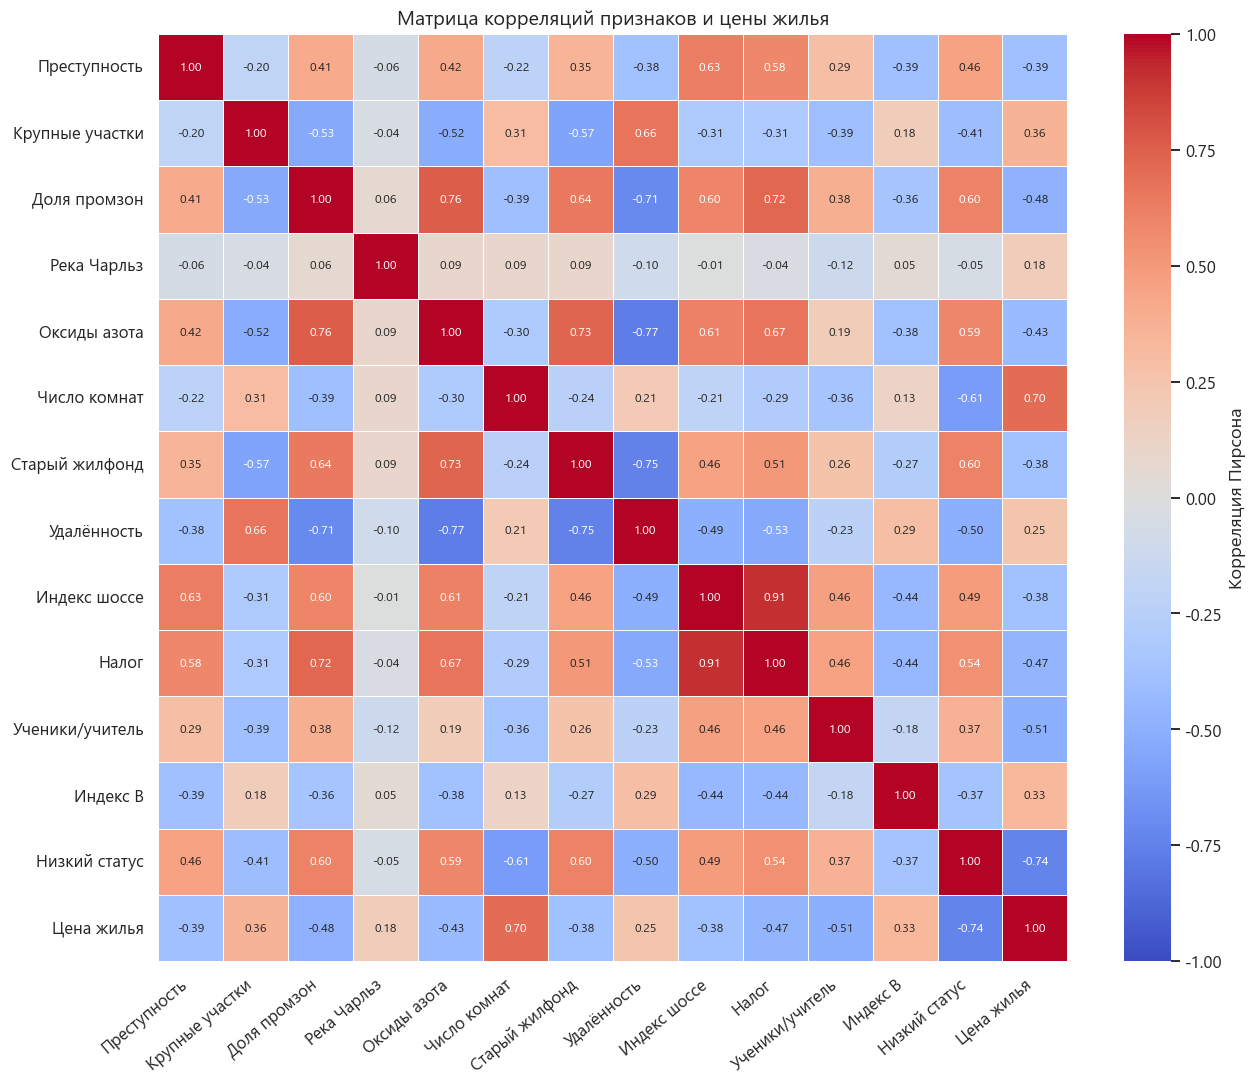

Самые сильные связи между признаками:
  Индекс шоссе — Налог: +0.910
  Оксиды азота — Удалённость: -0.769
  Доля промзон — Оксиды азота: +0.764
  Старый жилфонд — Удалённость: -0.748
  Оксиды азота — Старый жилфонд: +0.731
  Доля промзон — Налог: +0.721
  Доля промзон — Удалённость: -0.708
  Оксиды азота — Налог: +0.668

Связь с ценой жилья:
Низкий статус     -0.738
Ученики/учитель   -0.508
Доля промзон      -0.484
Налог             -0.469
Оксиды азота      -0.427
Преступность      -0.388
Индекс шоссе      -0.382
Старый жилфонд    -0.377
Река Чарльз        0.175
Удалённость        0.250
Индекс B           0.333
Крупные участки    0.360
Число комнат       0.695

ФАКТОР ИНФЛЯЦИИ ДИСПЕРСИИ (по стандартизированному train):
        Признак   VIF
          Налог 8.943
   Индекс шоссе 7.658
   Оксиды азота 4.469
    Удалённость 4.169
   Доля промзон 3.878
 Старый жилфонд 2.990
  Низкий статус 2.818
Крупные участки 2.466
   Число комнат 1.948
Ученики/учитель 1.851
   Преступность 1.713
       

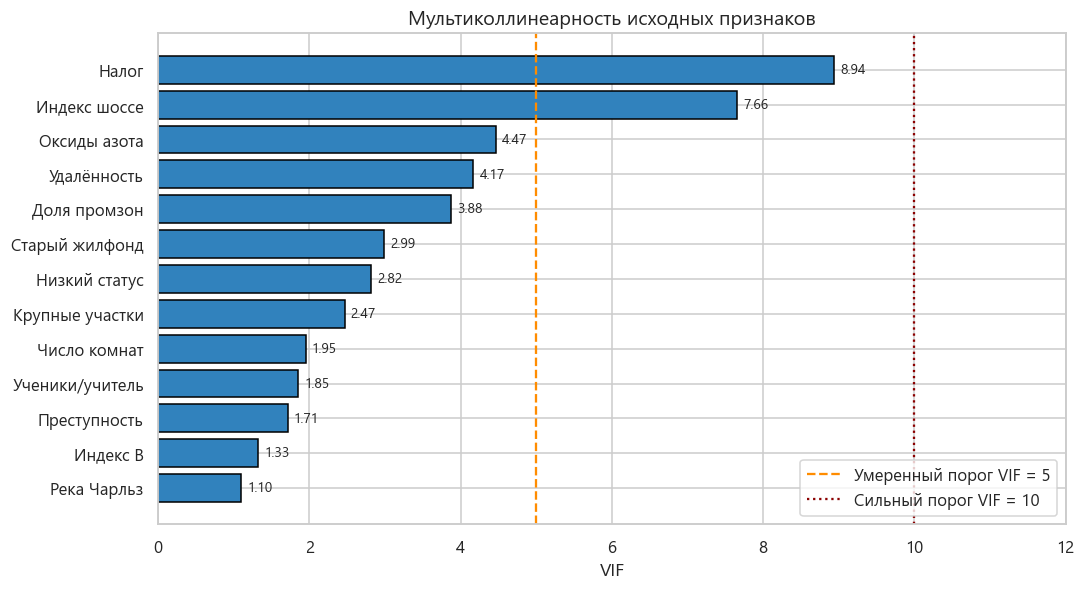

In [ ]:
corr_matrix = df_ru.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    vmin=-1, vmax=1, linewidths=0.4, annot_kws={"size": 8},
    cbar_kws={"label": "Корреляция Пирсона"},
)
plt.title("Матрица корреляций признаков и цены жилья")
plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

pairs = []
for i, left in enumerate(feature_names):
    for right in feature_names[i + 1:]:
        r = corr_matrix.loc[left, right]
        pairs.append((abs(r), left, right, r))
pairs.sort(reverse=True)
print("Самые сильные связи между признаками:")
for _, left, right, r in pairs[:8]:
    print(f"  {left} — {right}: {r:+.3f}")

print("\nСвязь с ценой жилья:")
print(corr_matrix["Цена жилья"].drop("Цена жилья").sort_values().round(3).to_string())

vif_df = pd.DataFrame({
    "Признак": feature_names,
    "VIF": [variance_inflation_factor(X_train_scaled.values, i) for i in range(len(feature_names))],
})
vif_df = vif_df.sort_values("VIF", ascending=False).reset_index(drop=True)
print("\nФАКТОР ИНФЛЯЦИИ ДИСПЕРСИИ (по стандартизированному train):")
print(vif_df.round(3).to_string(index=False))

plt.figure(figsize=(10, 5.5))
order = vif_df.sort_values("VIF")
bars = plt.barh(order["Признак"], order["VIF"], color="#3182bd", edgecolor="black")
plt.axvline(5, color="darkorange", linestyle="--", linewidth=1.5, label="Умеренный порог VIF = 5")
plt.axvline(10, color="darkred", linestyle=":", linewidth=1.5, label="Сильный порог VIF = 10")
plt.xlabel("VIF")
plt.title("Мультиколлинеарность исходных признаков")
for bar in bars:
    val = bar.get_width()
    plt.text(val + 0.08, bar.get_y() + bar.get_height() / 2, f"{val:.2f}", va="center", fontsize=9)
plt.xlim(0, 12)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 4. Ход работы

### Пояснение к корреляциям и VIF

С ценой сильнее всего связаны **низкий статус** (\(r = -0.74\)) и **число комнат** (\(r = +0.70\)). Дальше идут ученики на учителя (−0.51), доля промзон (−0.48), налог (−0.47), оксиды азота (−0.43). Река Чарльз почти не коррелирует с ценой поодиночке (\(r = +0.18\)), но в множественной модели ещё может дать небольшую надбавку.

Между признаками картина другая. Индекс шоссе и налог коррелируют на **+0.91**. Это не «две похожие идеи», а одна группа из 132 районов, у которых оба поля константны (24 и 666). Рядом с ними клубок промышленно-транспортных признаков: оксиды азота с удалённостью (−0.77), промзоны с оксидами азота (+0.76), старый жилфонд с удалённостью (−0.75), оксиды азота со старым фондом (+0.73). Удалённые от работы районы одновременно чище и новее, поэтому попарная корреляция удалённости с ценой положительная, хотя «дальше от работы» само по себе цену не повышает.

VIF отвечает на вопрос, насколько признак линейно восстанавливается по остальным:

\[
VIF_i = \frac{1}{1 - R_i^2}.
\]

Ориентир такой: VIF < 5 — зависимости почти нет, от 5 до 10 — умеренная мультиколлинеарность, выше 10 — оценки коэффициентов уже плохо разделены. На обучающей выборке **налог имеет VIF = 8.94, индекс шоссе — 7.66**. До сильного порога 10 они не доходят, но оба выше 5: коэффициенты этих двух признаков будут делить один и тот же эффект и могут даже сменить знак относительно попарной корреляции. Оксиды азота (4.47) и удалённость (4.17) рядом с порогом. Число комнат, низкий статус и река почти ортогональны остальным (VIF около 1.1–2.8), их коэффициенты устойчивы.

Вывод: мультиколлинеарность есть, она сосредоточена в паре «шоссе — налог» и в промышленном блоке. Имеет смысл и регуляризация, и PCA. Критической (VIF ≫ 10) её назвать нельзя, поэтому ждать, что лассо резко обнулит половину признаков, не стоит.


In [ ]:
alphas = np.logspace(-3, 3, 25)
ridge_selector = RidgeCV(alphas=alphas, cv=5).fit(X_train_scaled, y_train)
lasso_selector = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=20000).fit(X_train_scaled, y_train)
ridge_alpha = float(ridge_selector.alpha_)
lasso_alpha = float(lasso_selector.alpha_)
print(f"Сетка alpha: от {alphas.min():.4g} до {alphas.max():.4g}, {len(alphas)} значений")
print(f"Выбранный alpha Ridge: {ridge_alpha:.4f}")
print(f"Выбранный alpha Lasso: {lasso_alpha:.4f}")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
models_orig = {
    "Линейная регрессия": LinearRegression(),
    f"Гребневая (Ridge, α={ridge_alpha:.2f})": Ridge(alpha=ridge_alpha),
    f"Лассо (Lasso, α={lasso_alpha:.3f})": Lasso(alpha=lasso_alpha, max_iter=20000),
}

results_orig = []
preds_orig = {}
for name, model in models_orig.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring="r2")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    preds_orig[name] = y_pred
    results_orig.append({
        "Модель": name,
        "R² (кросс-валидация)": cv_scores.mean(),
        "СКО R² (CV)": cv_scores.std(),
        "R² (тест)": r2_score(y_test, y_pred),
        "RMSE (тест, тыс. $)": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAPE (тест, %)": mean_absolute_percentage_error(y_test, y_pred) * 100,
    })

df_results_orig = pd.DataFrame(results_orig)
print("\nМОДЕЛИ НА 13 ИСХОДНЫХ ПРИЗНАКАХ")
print(df_results_orig.round(4).to_string(index=False))


Сетка alpha: от 0.001 до 1000, 25 значений
Выбранный alpha Ridge: 3.1623
Выбранный alpha Lasso: 0.0010

МОДЕЛИ НА 13 ИСХОДНЫХ ПРИЗНАКАХ
                   Модель  R² (кросс-валидация)  СКО R² (CV)  R² (тест)  RMSE (тест, тыс. $)  MAPE (тест, %)
       Линейная регрессия                0.7185       0.0784     0.6688               4.9286         16.8664
Гребневая (Ridge, α=3.16)                0.7190       0.0807     0.6678               4.9356         16.8379
   Лассо (Lasso, α=0.001)                0.7185       0.0786     0.6687               4.9289         16.8628


### Пояснение к моделям на исходных признаках

Модель одна и та же по форме:

\[
\hat y = w_0 + w_1 z_1 + \ldots + w_{13} z_{13},
\]

где \(z_j\) — стандартизированный признак. Различаются штрафы. Обычная регрессия минимизирует только сумму квадратов ошибок. Гребневая добавляет \(\alpha \sum w_j^2\) и уменьшает все веса. Лассо добавляет \(\alpha \sum |w_j|\) и умеет занулять слабые веса.

Штраф \(\alpha\) выбран на обучающей выборке, без теста. Для гребня кросс-валидация остановилась на **α = 3.16**. Для лассо оптимум упёрся в нижний край сетки, **α = 0.001**: более сильный L1-штраф качество только портит. Лассо в этой задаче почти совпадает с обычным методом наименьших квадратов.

Метрики на 102 районах теста:

| Модель | R² CV | R² тест | RMSE, тыс. $ | MAPE, % |
|---|---:|---:|---:|---:|
| Линейная | 0.719 | 0.669 | 4.93 | 16.87 |
| Ridge | 0.719 | 0.668 | 4.94 | 16.84 |
| Lasso | 0.719 | 0.669 | 4.93 | 16.86 |

R² около **0.67** значит, что линейная формула объясняет примерно две трети разброса цен на тесте. RMSE **4.93 тыс. $** — типичный промах около **4 900 долларов** при средней цене около 22 500. MAPE **16.9%** — в среднем прогноз отклоняется от фактической цены на 17 относительных процентов. Для дешёвого района в 10 тыс. $ это чувствительнее, чем для района в 40 тыс. $, поэтому MAPE и RMSE смотрят на ошибку по-разному: RMSE сильнее наказывает крупные промахи в долларах.

Кросс-валидация на train даёт R² около 0.72 со стандартным отклонением фолдов около 0.08. Тестовые 0.67 лежат внутри этого разброса: модель не разваливается на новых районах, но и не идеальна. Регуляризация почти ничего не меняет. Это согласуется с VIF: мультиколлинеарность умеренная, наблюдений (404) намного больше, чем признаков (13), занулять нечего.


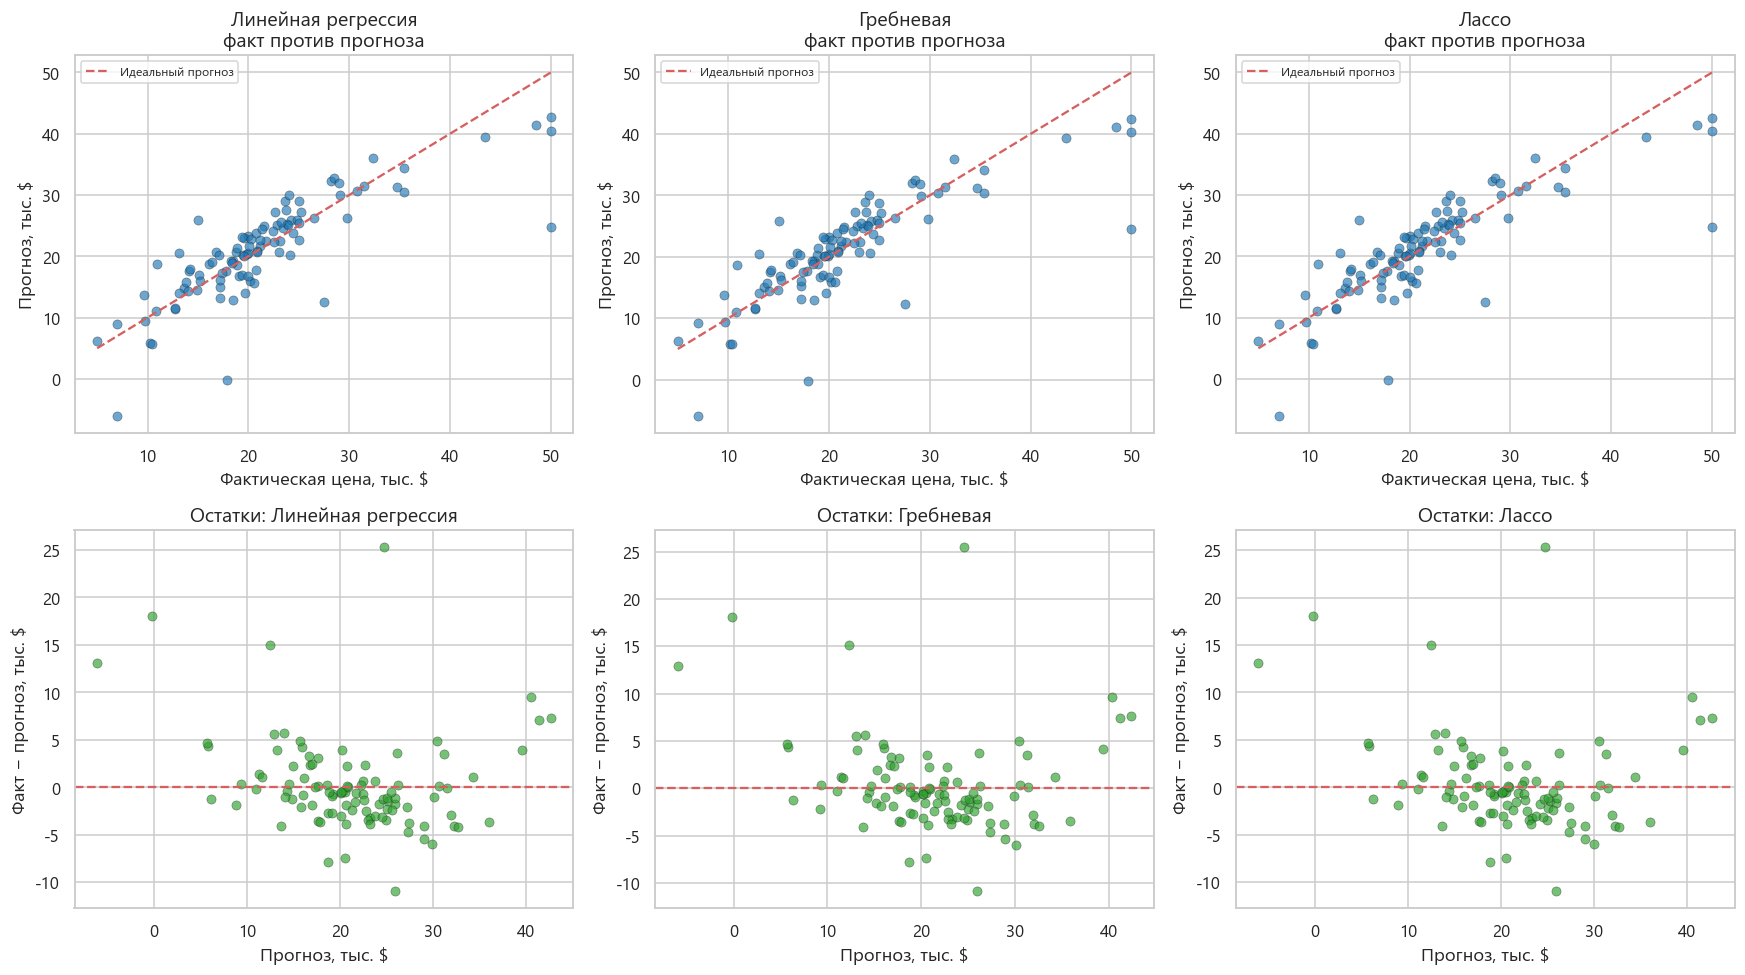

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for idx, (name, y_pred) in enumerate(preds_orig.items()):
    residuals = y_test.to_numpy() - y_pred
    short = name.split("(")[0].strip()

    axes[0, idx].scatter(y_test, y_pred, alpha=0.65, s=36, c="#1f77b4", edgecolor="k", linewidth=0.3)
    axes[0, idx].plot([5, 50], [5, 50], "r--", linewidth=1.5, label="Идеальный прогноз")
    axes[0, idx].set_title(f"{short}\nфакт против прогноза")
    axes[0, idx].set_xlabel("Фактическая цена, тыс. $")
    axes[0, idx].set_ylabel("Прогноз, тыс. $")
    axes[0, idx].legend(fontsize=8)

    axes[1, idx].scatter(y_pred, residuals, alpha=0.65, s=36, c="#2ca02c", edgecolor="k", linewidth=0.3)
    axes[1, idx].axhline(0, color="r", linestyle="--", linewidth=1.5)
    axes[1, idx].set_title(f"Остатки: {short}")
    axes[1, idx].set_xlabel("Прогноз, тыс. $")
    axes[1, idx].set_ylabel("Факт − прогноз, тыс. $")

plt.tight_layout()
plt.show()


### Пояснение к графикам прогноза и остатков

Три модели рисуют почти одну и ту же картинку — их метрики различаются в третьем знаке.

На верхнем ряду точки держатся около красной диагонали в середине диапазона, примерно от 12 до 35 тыс. $. Выше 40 облако отстаёт от диагонали: фактическая цена уже 50, а прогноз часто 30–40. Это след потолка. Внизу есть районы, которые модель считает дороже, чем они есть.

Остатки внизу не выглядят как ровная полоса одинаковой ширины. Разброс ошибки растёт вместе с прогнозом, и у правого края остатки систематически положительные (факт выше прогноза) именно там, где цена обрезана. Линейная формула по стандартизированным признакам этот потолок и изгиб `lstat` не воспроизводит. Регуляризация тут не помогает: она сужает веса, а не меняет форму зависимости.


Компонента  Собственное значение  Доля дисперсии  Накопленная доля
      ГК 1                6.0425          0.4637            0.4637
      ГК 2                1.4859          0.1140            0.5777
      ГК 3                1.2740          0.0978            0.6754
      ГК 4                0.8735          0.0670            0.7425
      ГК 5                0.8522          0.0654            0.8078
      ГК 6                0.6667          0.0512            0.8590
      ГК 7                0.5354          0.0411            0.9001
      ГК 8                0.3966          0.0304            0.9305
      ГК 9                0.2717          0.0208            0.9514
     ГК 10                0.2219          0.0170            0.9684
     ГК 11                0.1797          0.0138            0.9822
     ГК 12                0.1685          0.0129            0.9951
     ГК 13                0.0637          0.0049            1.0000


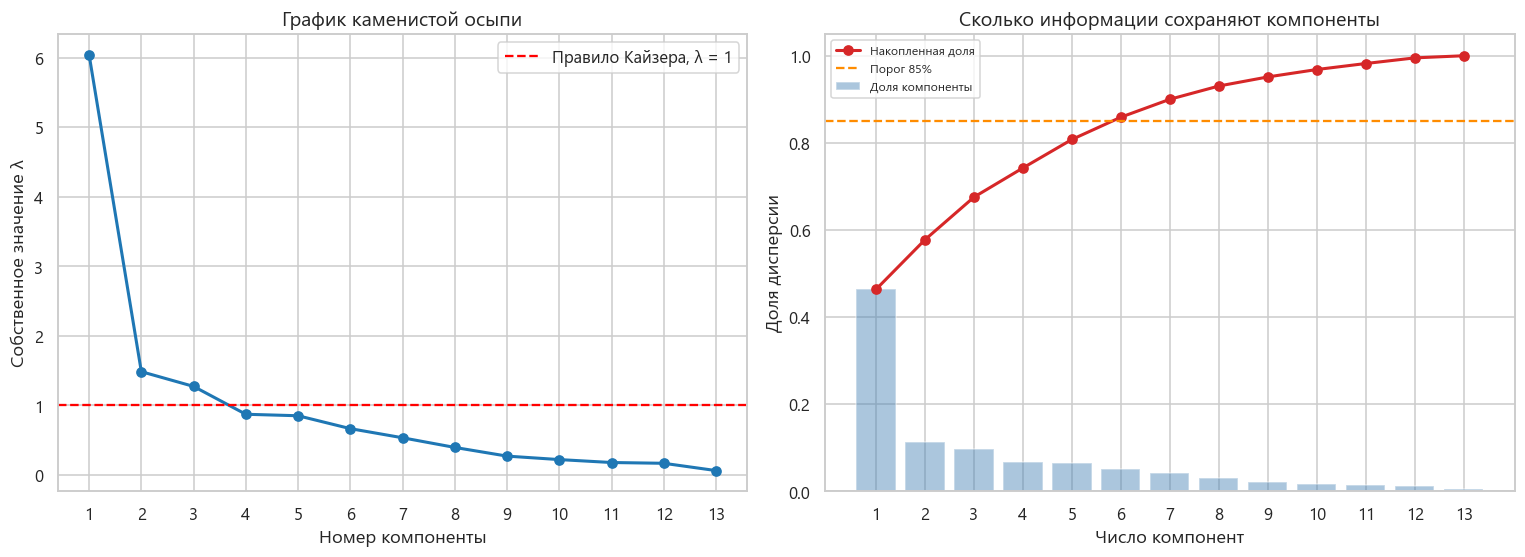

Компонент с λ ≥ 1: 3
Компонент для накопленной доли ≥ 85%: 6 (факт 85.9%)

Факторные нагрузки:
                  ГК 1   ГК 2   ГК 3   ГК 4   ГК 5   ГК 6
Преступность     0.246 -0.300  0.267 -0.022 -0.019  0.333
Крупные участки -0.260 -0.298  0.288 -0.122 -0.418  0.223
Доля промзон     0.351  0.109 -0.025  0.005 -0.091  0.023
Река Чарльз      0.018  0.435  0.329  0.604 -0.489 -0.244
Оксиды азота     0.345  0.239  0.074 -0.170 -0.112  0.118
Число комнат    -0.185  0.205  0.572 -0.045  0.512  0.045
Старый жилфонд   0.311  0.318 -0.056 -0.138  0.120  0.100
Удалённость     -0.327 -0.350 -0.003  0.102 -0.191 -0.070
Индекс шоссе     0.320 -0.266  0.315  0.189  0.063  0.128
Налог            0.337 -0.239  0.260  0.120 -0.029  0.154
Ученики/учитель  0.200 -0.343 -0.248  0.570  0.364 -0.246
Индекс B        -0.202  0.205 -0.296  0.403  0.048  0.805
Низкий статус    0.308 -0.101 -0.291 -0.147 -0.336  0.016


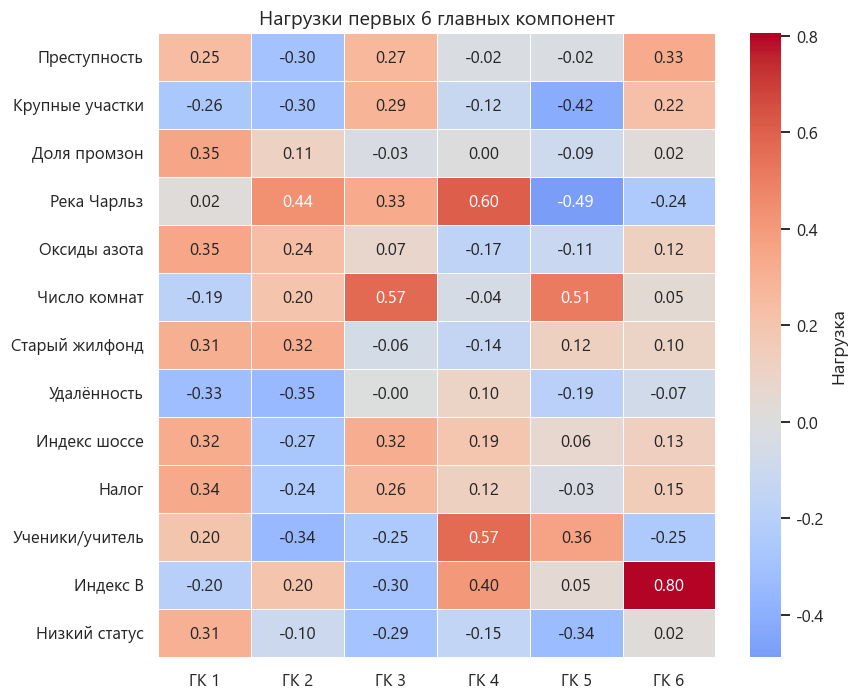

In [ ]:
pca_full = PCA().fit(X_train_scaled)
eigenvalues = pca_full.explained_variance_
exp_var_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var_ratio)

pca_table = pd.DataFrame({
    "Компонента": [f"ГК {i + 1}" for i in range(len(eigenvalues))],
    "Собственное значение": eigenvalues,
    "Доля дисперсии": exp_var_ratio,
    "Накопленная доля": cum_var,
})
print(pca_table.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
xs = np.arange(1, len(eigenvalues) + 1)
axes[0].plot(xs, eigenvalues, "o-", color="#1f77b4", linewidth=2)
axes[0].axhline(1.0, color="red", linestyle="--", label="Правило Кайзера, λ = 1")
axes[0].set_xticks(xs)
axes[0].set_xlabel("Номер компоненты")
axes[0].set_ylabel("Собственное значение λ")
axes[0].set_title("График каменистой осыпи")
axes[0].legend()

axes[1].bar(xs, exp_var_ratio, color="steelblue", alpha=0.45, label="Доля компоненты")
axes[1].plot(xs, cum_var, "o-", color="#d62728", linewidth=2, label="Накопленная доля")
axes[1].axhline(0.85, color="darkorange", linestyle="--", label="Порог 85%")
axes[1].set_xticks(xs)
axes[1].set_xlabel("Число компонент")
axes[1].set_ylabel("Доля дисперсии")
axes[1].set_title("Сколько информации сохраняют компоненты")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

k_opt = int(np.searchsorted(cum_var, 0.85) + 1)
print(f"Компонент с λ ≥ 1: {int((eigenvalues >= 1).sum())}")
print(f"Компонент для накопленной доли ≥ 85%: {k_opt} (факт {cum_var[k_opt - 1] * 100:.1f}%)")

pca = PCA(n_components=k_opt).fit(X_train_scaled)
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f"ГК {i + 1}" for i in range(k_opt)],
)
print("\nФакторные нагрузки:")
print(loadings.round(3).to_string())

plt.figure(figsize=(8, 6.5))
sns.heatmap(
    loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.4,
    cbar_kws={"label": "Нагрузка"},
)
plt.title(f"Нагрузки первых {k_opt} главных компонент")
plt.tight_layout()
plt.show()


### Пояснение к PCA

Перед разложением признаки уже стандартизированы. Иначе первая компонента просто повторила бы налог: у него самый большой исходный разброс. PCA ищет новые оси, которые не коррелируют друг с другом и по очереди забирают максимум оставшейся дисперсии.

График каменистой осыпи — собственные значения по убыванию. По **правилу Кайзера** оставляют компоненты с \(\lambda \ge 1\), то есть те, что объясняют больше одного исходного стандартизированного признака. Таких три: \(\lambda = 6.04,\ 1.49,\ 1.27\). Вместе они держат только **67.5%** дисперсии. Четвёртая и пятая близки к порогу (0.87 и 0.85), правило их отсекает формально.

Для прогноза 67% мало: в отброшенных 32% как раз сидят число комнат и низкий статус, а они главные для цены. Поэтому рабочее число компонент выбрано по накопленной дисперсии: **6 компонент покрывают 85.9%**. Размерность падает с 13 до 6, оси ортогональны.

Как читать нагрузки (знак оси условный, важен состав):

- **ГК 1, 46.4%.** Промышленно-транспортный фон. В одну сторону смотрят доля промзон, оксиды азота, налог, индекс шоссе, старый фонд, низкий статус и преступность. В другую — удалённость от работы и крупные участки. Это та самая связка, которую VIF не мог разделить. Теперь она упакована в одну ось.
- **ГК 2, 11.4%.** Отдельный контраст: река Чарльз и более старый фонд против удалённости, высокой нагрузки на учителя и преступности.
- **ГК 3, 9.8%.** Качество дома: наибольшая нагрузка у числа комнат (+0.57), рядом река и индекс шоссе, в минусе низкий статус. Именно эта ось несёт «дорогие просторные дома», которые первая компонента почти не видит.
- **ГК 4–6** добирают остаток до 85.9%. Шестая заметно выделяет индекс B (нагрузка около +0.80): эта переменная слабо встроена в промышленный фактор и живёт отдельной осью.

Дальше в регрессию идут только эти шесть координат, посчитанные преобразованием, которое обучено на train и применено к test.


In [ ]:
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
pca_names = [f"ГК {i + 1}" for i in range(k_opt)]

vif_pca = pd.DataFrame({
    "Компонента": pca_names,
    "VIF": [variance_inflation_factor(X_train_pca, i) for i in range(k_opt)],
})
print("VIF главных компонент (ожидается около 1 — оси не коррелируют):")
print(vif_pca.round(3).to_string(index=False))

models_pca = {
    "Линейная (PCA)": LinearRegression(),
    f"Ridge PCA (α={ridge_alpha:.2f})": Ridge(alpha=ridge_alpha),
    f"Lasso PCA (α={lasso_alpha:.3f})": Lasso(alpha=lasso_alpha, max_iter=20000),
}
results_pca = []
preds_pca = {}
for name, model in models_pca.items():
    cv_scores = cross_val_score(model, X_train_pca, y_train, cv=kf, scoring="r2")
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)
    preds_pca[name] = y_pred
    results_pca.append({
        "Модель": name,
        "R² (кросс-валидация)": cv_scores.mean(),
        "СКО R² (CV)": cv_scores.std(),
        "R² (тест)": r2_score(y_test, y_pred),
        "RMSE (тест, тыс. $)": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAPE (тест, %)": mean_absolute_percentage_error(y_test, y_pred) * 100,
    })

df_results_pca = pd.DataFrame(results_pca)
print(f"\nМОДЕЛИ НА {k_opt} ГЛАВНЫХ КОМПОНЕНТАХ")
print(df_results_pca.round(4).to_string(index=False))


VIF главных компонент (ожидается около 1 — оси не коррелируют):
Компонента  VIF
      ГК 1  1.0
      ГК 2  1.0
      ГК 3  1.0
      ГК 4  1.0
      ГК 5  1.0
      ГК 6  1.0

МОДЕЛИ НА 6 ГЛАВНЫХ КОМПОНЕНТАХ
             Модель  R² (кросс-валидация)  СКО R² (CV)  R² (тест)  RMSE (тест, тыс. $)  MAPE (тест, %)
     Линейная (PCA)                0.6837       0.1013     0.5958               5.4442         17.7624
 Ridge PCA (α=3.16)                0.6839       0.1015     0.5969               5.4367         17.7283
Lasso PCA (α=0.001)                0.6837       0.1012     0.5959               5.4436         17.7591


### Пояснение к моделям на главных компонентах

VIF всех шести компонент равен **1.00**. Мультиколлинеарность, которая была у налога и индекса шоссе, снята: новые признаки не коррелируют, и коэффициент при одной оси больше не «отъедает» эффект другой.

Качество на тесте:

| Модель | R² CV | R² тест | RMSE, тыс. $ | MAPE, % |
|---|---:|---:|---:|---:|
| Линейная | 0.684 | 0.596 | 5.44 | 17.76 |
| Ridge | 0.684 | 0.597 | 5.44 | 17.73 |
| Lasso | 0.684 | 0.596 | 5.44 | 17.76 |

Три модели снова неотличимы. Чуть лучший тестовый R² у гребня — **0.597**. Кросс-валидация просела с 0.72 до 0.68, разброс фолдов вырос до 0.10: прогноз стал немного менее устойчивым, потому что 14% дисперсии признаков отброшено, и внутри этого хвоста была полезная для цены информация.

RMSE около **5.44 тыс. $** — промах примерно на 5 400 долларов. MAPE около **17.7%**.


     Тип          Пространство  R² (кросс-валидация)  R² (тест)  RMSE (тест, тыс. $)  MAPE (тест, %)
Линейная Исходные 13 признаков                0.7185     0.6688               4.9286         16.8664
   Ridge Исходные 13 признаков                0.7190     0.6678               4.9356         16.8379
   Lasso Исходные 13 признаков                0.7185     0.6687               4.9289         16.8628
Линейная   6 главных компонент                0.6837     0.5958               5.4442         17.7624
   Ridge   6 главных компонент                0.6839     0.5969               5.4367         17.7283
   Lasso   6 главных компонент                0.6837     0.5959               5.4436         17.7591


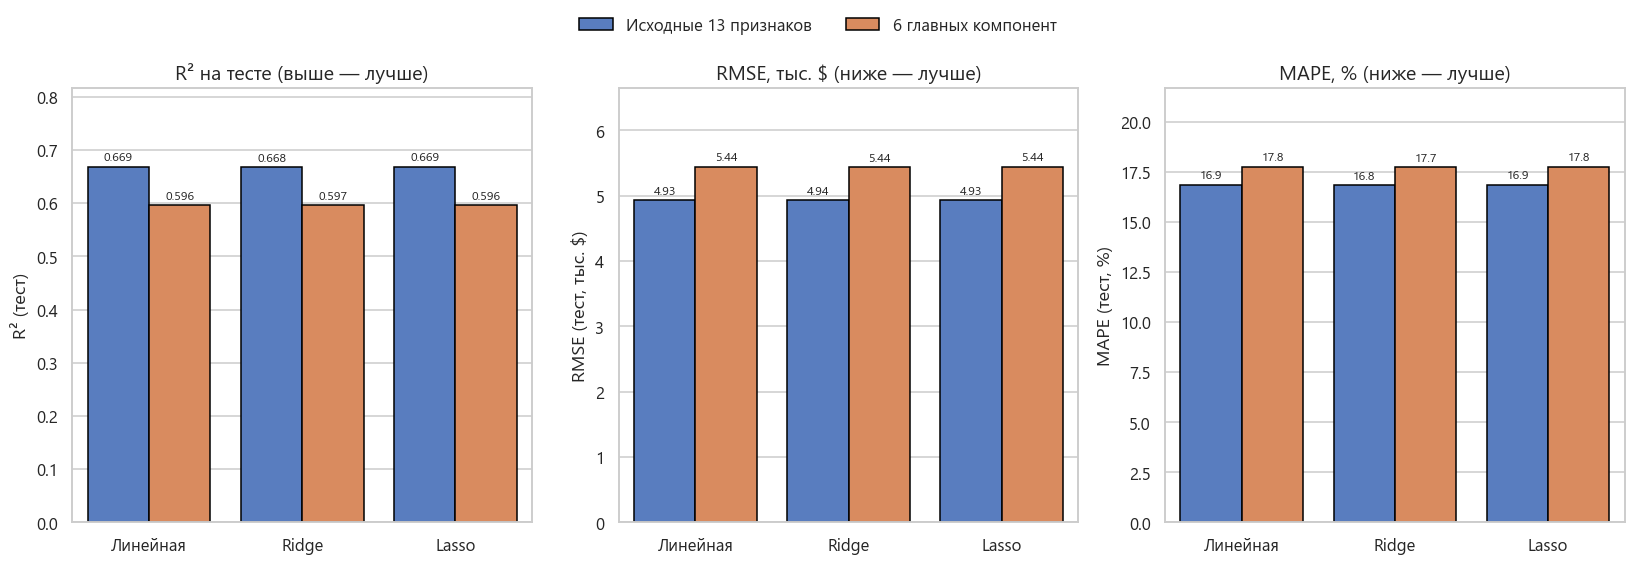

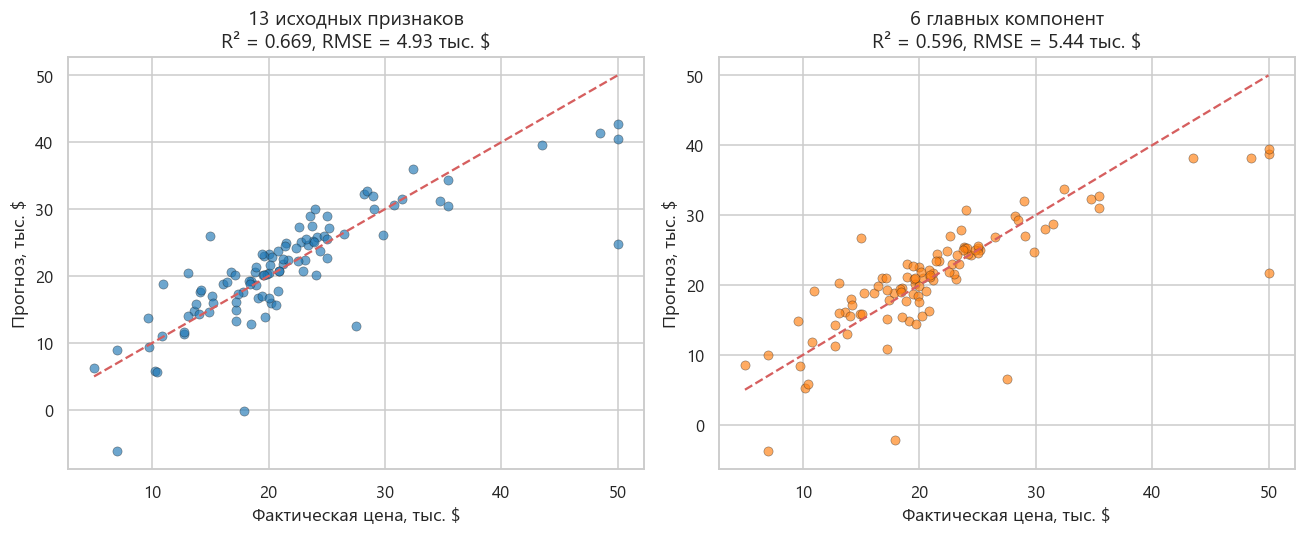

In [ ]:
cmp_orig = df_results_orig.copy()
cmp_pca = df_results_pca.copy()
cmp_orig["Пространство"] = "Исходные 13 признаков"
cmp_pca["Пространство"] = f"{k_opt} главных компонент"
cmp_orig["Тип"] = ["Линейная", "Ridge", "Lasso"]
cmp_pca["Тип"] = ["Линейная", "Ridge", "Lasso"]
all_models = pd.concat([cmp_orig, cmp_pca], ignore_index=True)
show_cols = [
    "Тип", "Пространство", "R² (кросс-валидация)", "R² (тест)",
    "RMSE (тест, тыс. $)", "MAPE (тест, %)",
]
print(all_models[show_cols].round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
metric_specs = [
    ("R² (тест)", "R² на тесте (выше — лучше)", ".3f"),
    ("RMSE (тест, тыс. $)", "RMSE, тыс. $ (ниже — лучше)", ".2f"),
    ("MAPE (тест, %)", "MAPE, % (ниже — лучше)", ".1f"),
]
for ax, (metric, title, fmt) in zip(axes, metric_specs):
    sns.barplot(
        data=all_models, x="Тип", y=metric, hue="Пространство",
        ax=ax, edgecolor="black",
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.set_ylim(0, all_models[metric].max() * 1.22)
    for container in ax.containers:
        ax.bar_label(container, fmt=f"%{fmt}", fontsize=8, padding=2)
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.08))
plt.tight_layout()
plt.show()

lin_name = "Линейная регрессия"
pca_lin_name = "Линейная (PCA)"
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, title, color in [
    (axes[0], preds_orig[lin_name], "13 исходных признаков", "#1f77b4"),
    (axes[1], preds_pca[pca_lin_name], f"{k_opt} главных компонент", "#ff7f0e"),
]:
    ax.scatter(y_test, pred, alpha=0.65, s=36, c=color, edgecolor="k", linewidth=0.3)
    ax.plot([5, 50], [5, 50], "r--", linewidth=1.5)
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    ax.set_title(f"{title}\nR² = {r2:.3f}, RMSE = {rmse:.2f} тыс. $")
    ax.set_xlabel("Фактическая цена, тыс. $")
    ax.set_ylabel("Прогноз, тыс. $")
plt.tight_layout()
plt.show()


### Пояснение к сравнению

| | Исходные признаки | 6 главных компонент | Разница |
|---|---:|---:|---:|
| R² линейной модели | 0.669 | 0.596 | −0.073 |
| RMSE, тыс. $ | 4.93 | 5.44 | +0.52 |
| MAPE, % | 16.87 | 17.76 | +0.89 |

PCA не улучшил прогноз. Он сохранил около **89%** прежнего R² (0.596 / 0.669) и убрал корреляцию признаков: VIF стал равен 1. Цена этого — примерно **500 долларов** дополнительной типичной ошибки и потеря 7 пунктов R².

Так и должно быть на этих данных. Мультиколлинеарность была локальной (две-четыре связанные переменные, VIF < 10), а не тотальной. Гребень и лассо поэтому почти не отличались от обычной регрессии уже на исходных признаках. Сжатие до 6 осей выбрасывает 14% дисперсии признаков, и часть её была полезна для цены, в первую очередь тонкие различия числа комнат и статуса, которые не целиком легли в первые компоненты.

Практический выбор зависит от задачи. Если нужен минимальный промах в долларах — оставить 13 стандартизированных признаков и обычную или гребневую регрессию (R² ≈ 0.67, RMSE ≈ 4.93 тыс. $). Если нужно говорить о независимых факторах и не спорить, «что важнее, налог или шоссе», — брать главные компоненты и мириться с R² ≈ 0.60.

Оставшаяся ошибка даже у лучшей модели не случайный шум. Её кормят потолок цены на 50 тыс. $, изгиб связи статуса с ценой, крайние значения преступности и то, что в таблице нет состояния дома, года сделки и типа здания. Поднять точность можно логарифмом преступности, нелинейным членом по `lstat` и отдельной обработкой обрезанных цен. К регуляризации и к дальнейшему уменьшению числа компонент это уже не сводится.


In [ ]:
coef_table = pd.DataFrame({
    "Признак": feature_names,
    "Линейная": models_orig["Линейная регрессия"].coef_,
    f"Ridge α={ridge_alpha:.2f}": models_orig[f"Гребневая (Ridge, α={ridge_alpha:.2f})"].coef_,
    f"Lasso α={lasso_alpha:.3f}": models_orig[f"Лассо (Lasso, α={lasso_alpha:.3f})"].coef_,
})
coef_table = coef_table.sort_values("Линейная", key=lambda s: s.abs(), ascending=False)
print("КОЭФФИЦИЕНТЫ НА СТАНДАРТИЗИРОВАННЫХ ПРИЗНАКАХ")
print("Единица: тыс. $ цены при увеличении признака на 1 стандартное отклонение")
print(coef_table.round(3).to_string(index=False))
print(f"\nСвободный член линейной модели: {models_orig['Линейная регрессия'].intercept_:.3f} тыс. $")
print("Нули среди коэффициентов лассо:", int(np.sum(np.abs(models_orig[f'Лассо (Lasso, α={lasso_alpha:.3f})'].coef_) < 1e-8)))


КОЭФФИЦИЕНТЫ НА СТАНДАРТИЗИРОВАННЫХ ПРИЗНАКАХ
Единица: тыс. $ цены при увеличении признака на 1 стандартное отклонение
        Признак  Линейная  Ridge α=3.16  Lasso α=0.001
  Низкий статус    -3.612        -3.573         -3.611
   Число комнат     3.145         3.163          3.146
    Удалённость    -3.082        -2.969         -3.075
   Индекс шоссе     2.251         2.022          2.233
Ученики/учитель    -2.038        -2.007         -2.036
   Оксиды азота    -2.022        -1.926         -2.016
          Налог    -1.767        -1.559         -1.749
       Индекс B     1.130         1.122          1.128
   Преступность    -1.002        -0.972         -0.999
    Река Чарльз     0.719         0.730          0.719
Крупные участки     0.696         0.641          0.691
   Доля промзон     0.278         0.202          0.269
 Старый жилфонд    -0.176        -0.179         -0.174

Свободный член линейной модели: 22.797 тыс. $
Нули среди коэффициентов лассо: 0


### Пояснение к коэффициентам

Свободный член **22.80 тыс. $** — средняя цена на обучающей выборке. Так выходит всегда, когда признаки центрированы: при «среднем районе» прогноз равен средней цене.

Коэффициент читается так: на сколько тысяч долларов меняется прогноз, если признак вырастает на одно своё стандартное отклонение, а остальные держатся на месте.

Сильнее всего цену тянут вниз **низкий статус (−3.61)** и вверх **число комнат (+3.15)**. Это те же два лидера, что и на диаграммах рассеяния. Дальше идут удалённость (**−3.08**), индекс шоссе (**+2.25**), ученики на учителя (**−2.04**), оксиды азота (**−2.02**) и налог (**−1.77**).

Два знака расходятся с попарной корреляцией, и это прямое следствие мультиколлинеарности:

- Удалённость попарно коррелирует с ценой **положительно** (+0.25), а коэффициент **отрицательный**. Дальние районы чище и менее промышленные, и этот плюс уже сидит в оксидах азота и доле промзон. Когда их удерживают постоянными, оставшийся эффект расстояния — минус: дальше от работы жить менее удобно.
- Индекс шоссе попарно связан с ценой **отрицательно** (−0.38), а коэффициент **положительный**. Отрицательный эффект этой группы районов забирает налог (у них у всех ставка 666). Оставшийся кусок индекса шоссе меняет знак. По отдельности эти два коэффициента интерпретировать опасно — отсюда и были VIF 8.9 и 7.7.

Гребень с α = 3.16 слегка поджимает веса (низкий статус с −3.61 до −3.57, индекс шоссе с +2.25 до +2.02), не меняя знаков. Лассо с α = 0.001 не обнулило ни одного коэффициента: каждый признак хоть немного, но нужен, а штраф слишком слабый, чтобы кого-то выкинуть. Это согласуется с кросс-валидацией, которая и выбрала почти нулевой штраф.


## 5. Заключение

На 506 районах Boston Housing построены и сравнены линейная, гребневая и лассо-регрессия до и после метода главных компонент.

1. В данных нет пропусков и дубликатов. Цена в среднем 22.5 тыс. $, распределение скошено, 16 районов обрезаны на 50 тыс. $. Масштабы признаков несопоставимы, поэтому перед регуляризацией и PCA выполнена стандартизация по обучающей выборке (404 / 102).
2. Цену линейно тянут низкий социальный статус (r = −0.74) и число комнат (r = +0.70). Индекс шоссе и налог коррелируют на +0.91, потому что 132 района имеют пару значений (24, 666). VIF этих признаков 8.94 и 7.66 — мультиколлинеарность умеренная, не критическая.
3. На исходных признаках три модели почти совпали: **R² ≈ 0.669, RMSE ≈ 4.93 тыс. $, MAPE ≈ 16.9%**. Пятифолдовая кросс-валидация даёт R² ≈ 0.72. Лучший штраф гребня α = 3.16, лассо остаётся при α = 0.001 и не зануляет веса.
4. По правилу Кайзера значимы 3 компоненты (67.5% дисперсии). Для прогноза взяты **6 компонент, 85.9% дисперсии**. Первая ось собирает промышленный и транспортный фон, третья — число комнат. VIF компонент равен 1.
5. На главных компонентах качество ниже: **R² ≈ 0.596, RMSE ≈ 5.44 тыс. $, MAPE ≈ 17.7%**. PCA устраняет мультиколлинеарность и сокращает число признаков с 13 до 6, но не повышает точность. Для прогноза цены предпочтительны исходные стандартизированные признаки.

Ошибка, которая остаётся, связана с потолком цены, нелинейностью статуса и тяжёлым хвостом преступности. Её имеет смысл снимать преобразованием признаков, а не более сильной регуляризацией.

## 6. Список источников

1. Harrison D., Rubinfeld D. L. Hedonic prices and the demand for clean air // Journal of Environmental Economics and Management. — 1978. — Vol. 5. — P. 81–102.
2. Hastie T., Tibshirani R., Friedman J. The Elements of Statistical Learning. — 2nd ed. — Springer, 2009.
3. Bishop C. M. Pattern Recognition and Machine Learning. — Springer, 2006.
4. Джеймс Г., Уиттен Д., Хасти Т., Тибширани Р. Введение в статистическое обучение. — М.: ДМК Пресс, 2016.
5. Boston Housing dataset, Kaggle: https://www.kaggle.com/datasets/arunjangir245/boston-housing-dataset
6. StatLib / UCI Housing (описание полей): https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.names
7. Документация scikit-learn, линейные модели и PCA: https://scikit-learn.org/stable/modules/linear_model.html и https://scikit-learn.org/stable/modules/decomposition.html
8. Документация statsmodels, variance inflation factor: https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html

## 7. Приложение

Полный листинг — кодовые ячейки этого ноутбука в порядке выполнения: загрузка, описательная статистика, графики, разбиение и стандартизация, корреляции и VIF, три регрессии, графики остатков, PCA, повтор регрессий, сравнение метрик и таблица коэффициентов. Отдельный дублирующий файл с тем же кодом не прикладывается.
